# Data Collection and Preparation

In [1]:
import os
print(os.getcwd())

C:\python\dropout_predictor


In [20]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

print("Tools loaded successfully!")

Tools loaded successfully!


# Load the Data

In [6]:
# reading and loading our csv file
df = pd.read_csv('data.csv')

# displaying the first set of our data set
df.head()

,student_id,state,geopolitical_zone,location_type,age,gender,school_level,school_type,household_income_quintile,fee_payment_pct,...,score_trend,consecutive_absences_days,repeated_a_class,student_teacher_ratio,school_has_wash,school_has_feeding_program,disruption_event_last_year,dropout_risk_score,risk_tier,dropped_out
0,NG-STU-0001,Osun,South-West,Rural,15,Male,SSS,Private,3,24,...,Declining,2,1,> 60:1,0,0,1,0.267,Medium,0
1,NG-STU-0002,Benue,North-Central,Rural,10,Male,Primary,Mission/Community,4,92,...,Stable,1,0,< 40:1,1,0,0,0.053,Low,0
2,NG-STU-0003,Enugu,South-East,Rural,11,Male,Primary,Public,2,15,...,Stable,1,0,> 60:1,0,1,1,0.326,Medium,0
3,NG-STU-0004,Jigawa,North-West,Urban,15,Male,SSS,Public,4,66,...,Stable,0,0,> 60:1,1,0,0,0.246,Low,0
4,NG-STU-0005,Enugu,South-East,Rural,13,Male,JSS,Public,4,55,...,Stable,3,0,< 40:1,1,0,0,0.352,Medium,1


In [8]:
df.columns

Index(['student_id', 'state', 'geopolitical_zone', 'location_type', 'age',
       'gender', 'school_level', 'school_type', 'household_income_quintile',
       'fee_payment_pct', 'distance_to_school_km', 'two_parent_household',
       'parental_education_level', 'child_labour_involved',
       'early_marriage_risk', 'attendance_rate_pct', 'avg_term_test_score',
       'score_trend', 'consecutive_absences_days', 'repeated_a_class',
       'student_teacher_ratio', 'school_has_wash',
       'school_has_feeding_program', 'disruption_event_last_year',
       'dropout_risk_score', 'risk_tier', 'dropped_out'],
      dtype='object')

# Features Selection

In [11]:
# Exporting out the Y axis for the project which is the depency
y = df['dropped_out']

#Exporting out the X axis for the project
x = df[['attendance_rate_pct', 'avg_term_test_score']]

# Data Splitting (test and train)

In [13]:
# 80% to learn, 20% for the final test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Training The model

In [15]:
# 1. Create the AI model
model = RandomForestClassifier()

# 2. Start the training (supervised learning)
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# Evaluation Metrics

In [16]:
model.score(x_test, y_test)

0.6375

# Generate the Metrics Report

In [30]:
y_predict = model.predict(x_test)

# 2. Print the text-based report
print("--- Model Accuracy ---")
print(f"{accuracy_score(y_test, y_predict):.2%}")

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_predict))

--- Model Accuracy ---
63.75%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.70      0.85      0.77       169
           1       0.28      0.14      0.19        71

    accuracy                           0.64       240
   macro avg       0.49      0.49      0.48       240
weighted avg       0.58      0.64      0.60       240



## Visualizing the Confusion Matrix

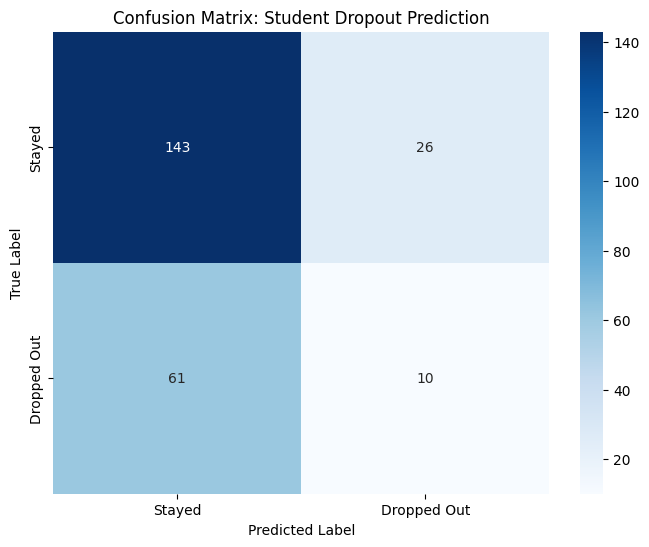

In [31]:
# 3. Create the Confusion Matrix
cm = confusion_matrix(y_test, y_predict)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed', 'Dropped Out'], 
            yticklabels=['Stayed', 'Dropped Out'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Student Dropout Prediction')
plt.show()

# Saving the "Brain"

In [33]:
# Save the model
joblib.dump(model, "student_dropout_model.pkl")
print("Brain saved as student_dropout_model.pkl. You can now use this file in your Streamlit app!")

Brain saved as student_dropout_model.pkl. You can now use this file in your Streamlit app!
